In [32]:
import os
import sys
import glob
import pandas as pd
sys.path.append("../utils")

In [33]:
def concat_ndvi_files(folder_path):
    """
    Input folder path to this function to concatenate all *.csv files by 'inspection_id'.
    This function is designed only for output files from the notebook `ndvi_calculate.ipynb`.

    Example usage: concatenated = concat_ndvi_files("/capstone/wildfire_prep/ryan/data-preparation/code/07_ndvi_pystac/ndvi_files")
    """
    # read all csv files
    csv_files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))

    # read each, selecting only the two columns we need
    df_list = [pd.read_csv(fp)[["inspection_id", "mean_ndvi"]] for fp in csv_files]

    # stack them and reset the index
    concatenated = pd.concat(df_list, axis=0, ignore_index=True)
    return concatenated


In [34]:
concatenated = concat_ndvi_files("/capstone/wildfire_prep/ryan/data-preparation/code/07_ndvi_pystac/ndvi_files")

In [35]:
print(f"Shape of concatenated data:", concatenated.shape)
print(f"Number of NA Values in data:", concatenated.mean_ndvi.isna().sum())

Shape of concatenated data: (54064, 2)
Number of NA Values in data: 25


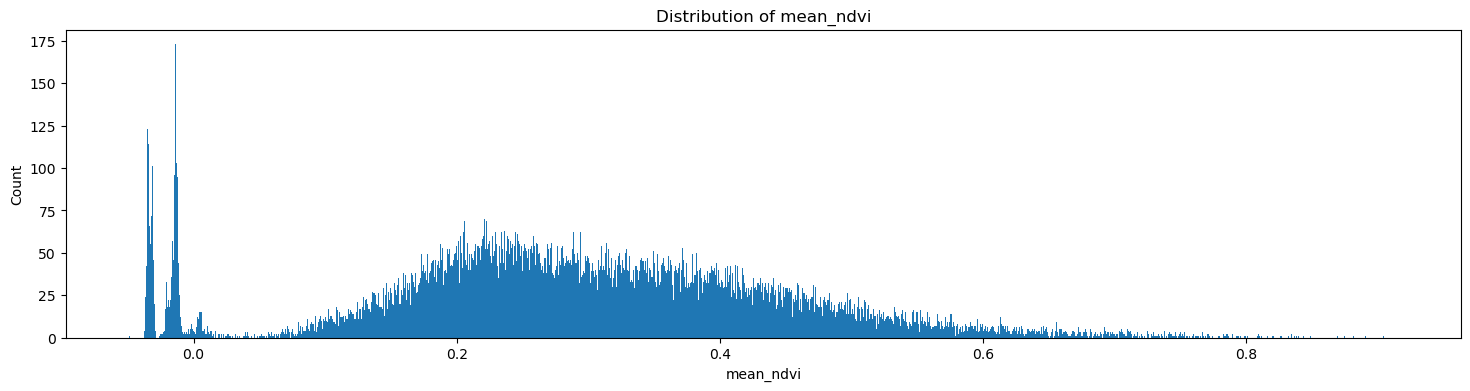

In [36]:
import matplotlib.pyplot as plt

values = concatenated["mean_ndvi"].dropna()

plt.figure(figsize = (18, 4))
plt.hist(values, bins=3000)
plt.xlabel("mean_ndvi")
plt.ylabel("Count")
plt.title("Distribution of mean_ndvi")
plt.show()
